# Student Performance Classification

## Objective

This classification experiment investigates whether early student
information can be used to identify students who may be at risk of
poor final academic performance.

The final grade (`G3`) is converted into a binary target:

- **At Risk:** G3 < 10
- **Not At Risk:** G3 >= 10

The classification models use the same 30 early-prediction features
used in the regression experiment. The intermediate grades G1 and G2
are excluded from the predictors because they would not represent an
early-prediction scenario.

### Import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Classification libraries loaded successfully.")

Classification libraries loaded successfully.


### Load the dataset

In [2]:
features_path = "../data/raw/student_performance_features.csv"
targets_path = "../data/raw/student_performance_targets.csv"

X = pd.read_csv(features_path)
targets = pd.read_csv(targets_path)

y_g3 = targets["G3"]

print("Features shape:", X.shape)
print("Target shape:", y_g3.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nG3 summary:")
print(y_g3.describe())

Features shape: (649, 30)
Target shape: (649,)

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

G3 summary:
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


## Classification Target Construction

The original `G3` variable is a continuous final-grade score ranging
from 0 to 20.

For the classification task, students are divided into two groups:

- **At Risk:** G3 < 10
- **Not At Risk:** G3 >= 10

The threshold is defined before model training and is applied only to
the target variable.

In [3]:
y = (y_g3 >= 10).astype(int)

class_labels = {
    0: "At Risk",
    1: "Not At Risk"
}

print("Classification target created.")
print("\nClass distribution:")
print(y.value_counts().sort_index())

print("\nClass percentages:")
print(
    (y.value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

Classification target created.

Class distribution:
G3
0    100
1    549
Name: count, dtype: int64

Class percentages:
G3
0    15.41
1    84.59
Name: proportion, dtype: float64


### Check class balance

In [4]:
class_distribution = pd.DataFrame({
    "Class": ["At Risk", "Not At Risk"],
    "Count": [
        (y == 0).sum(),
        (y == 1).sum()
    ],
    "Percentage": [
        (y == 0).mean() * 100,
        (y == 1).mean() * 100
    ]
})

class_distribution

,Class,Count,Percentage
0,At Risk,100,15.40832
1,Not At Risk,549,84.59168


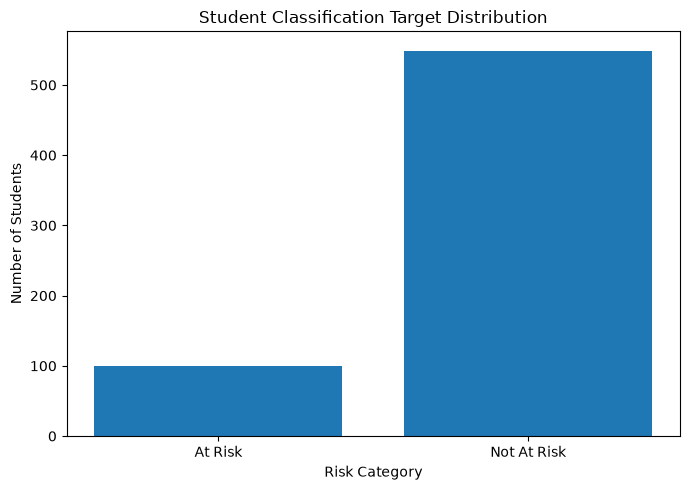

In [5]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Student Classification Target Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Remove G1/G2 if they somehow exist

In [6]:
excluded_grade_columns = [
    column for column in ["G1", "G2", "G3"]
    if column in X.columns
]

print("Excluded grade columns:", excluded_grade_columns)

Excluded grade columns: []


In [7]:
print("Classification feature count:", X.shape[1])

Classification feature count: 30


## Train-Test Split

The dataset is divided into training and testing subsets using an
80:20 ratio.

Stratified sampling is used to preserve the proportion of At Risk and
Not At Risk students in both subsets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nTesting class distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Training shape: (519, 30)
Testing shape: (130, 30)

Training class distribution:
G3
0    0.1541
1    0.8459
Name: proportion, dtype: float64

Testing class distribution:
G3
0    0.1538
1    0.8462
Name: proportion, dtype: float64


## Classification Preprocessing

Numerical variables are imputed using the median and standardized
using StandardScaler.

Categorical variables are imputed using the most frequent category
and transformed using one-hot encoding.

The preprocessing operations are placed inside a scikit-learn
pipeline so that transformations are learned only from the training
data during model evaluation.

In [9]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 17


## Stratified Cross-Validation

Five-fold stratified cross-validation is used for classification model
evaluation.

Stratification ensures that each fold maintains a similar proportion
of At Risk and Not At Risk students.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation configured.")

5-fold stratified cross-validation configured.


## Logistic Regression

Logistic Regression is used as the baseline classification model.

Because the dataset contains an imbalanced target, class-balanced
weighting is used so that the minority At Risk class receives greater
importance during model training.

The model is evaluated using accuracy, precision, recall, F1-score,
and five-fold stratified cross-validation.

In [11]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_pred = logistic_pipeline.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    zero_division=0
)

print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-score :", logistic_f1)

Logistic Regression
Accuracy : 0.6538461538461539
Precision: 0.8735632183908046
Recall   : 0.6909090909090909
F1-score : 0.7715736040609137


### Classification report

In [12]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["At Risk", "Not At Risk"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.21      0.45      0.29        20
 Not At Risk       0.87      0.69      0.77       110

    accuracy                           0.65       130
   macro avg       0.54      0.57      0.53       130
weighted avg       0.77      0.65      0.70       130



### Confusion matrix

In [13]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

print("Confusion Matrix:")
print(logistic_cm)

Confusion Matrix:
[[ 9 11]
 [34 76]]


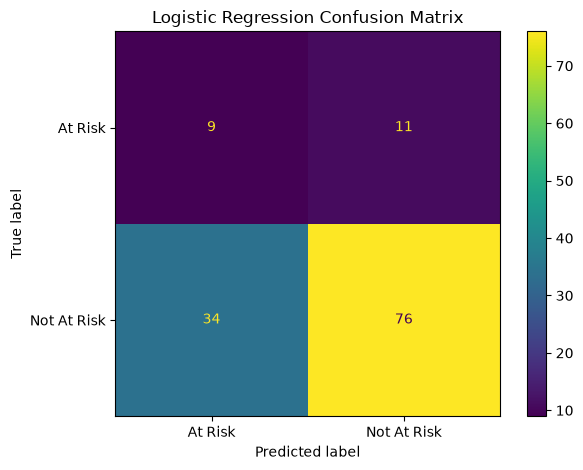

In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["At Risk", "Not At Risk"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### Cross-validation

In [15]:
logistic_cv_f1 = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression 5-Fold CV F1:")
print(logistic_cv_f1)

print("\nMean CV F1:", logistic_cv_f1.mean())
print("Std CV F1:", logistic_cv_f1.std())

Logistic Regression 5-Fold CV F1:
[0.90361446 0.83544304 0.86419753 0.88343558 0.89411765]

Mean CV F1: 0.8761616513102233
Std CV F1: 0.02420797430130943


## Decision Tree Classifier

A Decision Tree Classifier is evaluated as a nonlinear alternative to
Logistic Regression.

The model can capture nonlinear relationships and interactions between
student characteristics. Class-balanced weighting is used because the
At Risk class represents a minority of the observations.

The model is evaluated using accuracy, precision, recall, F1-score,
confusion matrix, and five-fold stratified cross-validation.

In [16]:
decision_tree_classifier_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_classifier_pipeline.fit(
    X_train,
    y_train
)

dt_classifier_pred = (
    decision_tree_classifier_pipeline.predict(
        X_test
    )
)

dt_classifier_accuracy = accuracy_score(
    y_test,
    dt_classifier_pred
)

dt_classifier_precision = precision_score(
    y_test,
    dt_classifier_pred,
    zero_division=0
)

dt_classifier_recall = recall_score(
    y_test,
    dt_classifier_pred,
    zero_division=0
)

dt_classifier_f1 = f1_score(
    y_test,
    dt_classifier_pred,
    zero_division=0
)

print("Decision Tree Classifier")
print("Accuracy :", dt_classifier_accuracy)
print("Precision:", dt_classifier_precision)
print("Recall   :", dt_classifier_recall)
print("F1-score :", dt_classifier_f1)

Decision Tree Classifier
Accuracy : 0.7076923076923077
Precision: 0.8461538461538461
Recall   : 0.8
F1-score : 0.822429906542056


### Classification report

In [17]:
print(
    classification_report(
        y_test,
        dt_classifier_pred,
        target_names=["At Risk", "Not At Risk"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.15      0.20      0.17        20
 Not At Risk       0.85      0.80      0.82       110

    accuracy                           0.71       130
   macro avg       0.50      0.50      0.50       130
weighted avg       0.74      0.71      0.72       130



### Confusion matrix

In [18]:
dt_classifier_cm = confusion_matrix(
    y_test,
    dt_classifier_pred
)

print("Decision Tree Confusion Matrix:")
print(dt_classifier_cm)

Decision Tree Confusion Matrix:
[[ 4 16]
 [22 88]]


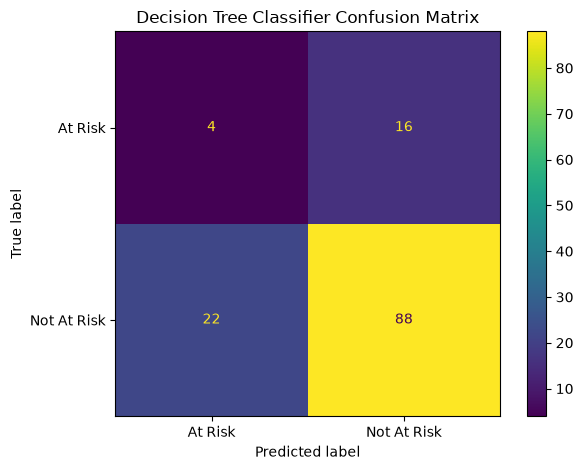

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_classifier_cm,
    display_labels=["At Risk", "Not At Risk"]
)

disp.plot()

plt.title("Decision Tree Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

### Cross-validation

In [20]:
dt_classifier_cv_f1 = cross_val_score(
    decision_tree_classifier_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Decision Tree Classifier 5-Fold CV F1:")
print(dt_classifier_cv_f1)

print("\nMean CV F1:", dt_classifier_cv_f1.mean())
print("Std CV F1:", dt_classifier_cv_f1.std())

Decision Tree Classifier 5-Fold CV F1:
[0.94054054 0.91428571 0.85549133 0.92655367 0.86857143]

Mean CV F1: 0.9010885370387672
Std CV F1: 0.03321315059597225


## Random Forest Classifier

A Random Forest Classifier is evaluated as an ensemble alternative to
Logistic Regression and Decision Tree classification.

Random Forest combines multiple decision trees and can capture
nonlinear relationships and interactions between student
characteristics.

Class-balanced weighting is used because the At Risk class is the
minority class.

The model is evaluated using accuracy, precision, recall, F1-score,
confusion matrix, and five-fold stratified cross-validation.

In [21]:
random_forest_classifier_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_classifier_pipeline.fit(
    X_train,
    y_train
)

rf_classifier_pred = (
    random_forest_classifier_pipeline.predict(
        X_test
    )
)

rf_classifier_accuracy = accuracy_score(
    y_test,
    rf_classifier_pred
)

rf_classifier_precision = precision_score(
    y_test,
    rf_classifier_pred,
    zero_division=0
)

rf_classifier_recall = recall_score(
    y_test,
    rf_classifier_pred,
    zero_division=0
)

rf_classifier_f1 = f1_score(
    y_test,
    rf_classifier_pred,
    zero_division=0
)

print("Random Forest Classifier")
print("Accuracy :", rf_classifier_accuracy)
print("Precision:", rf_classifier_precision)
print("Recall   :", rf_classifier_recall)
print("F1-score :", rf_classifier_f1)

Random Forest Classifier
Accuracy : 0.7615384615384615
Precision: 0.8691588785046729
Recall   : 0.8454545454545455
F1-score : 0.8571428571428571


### Classification report

In [22]:
print(
    classification_report(
        y_test,
        rf_classifier_pred,
        target_names=["At Risk", "Not At Risk"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.26      0.30      0.28        20
 Not At Risk       0.87      0.85      0.86       110

    accuracy                           0.76       130
   macro avg       0.57      0.57      0.57       130
weighted avg       0.78      0.76      0.77       130



### Confusion matrix

In [23]:
rf_classifier_cm = confusion_matrix(
    y_test,
    rf_classifier_pred
)

print("Random Forest Confusion Matrix:")
print(rf_classifier_cm)

Random Forest Confusion Matrix:
[[ 6 14]
 [17 93]]


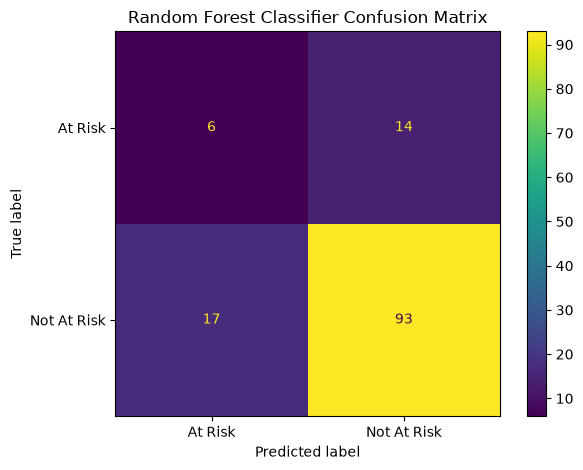

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_classifier_cm,
    display_labels=["At Risk", "Not At Risk"]
)

disp.plot()

plt.title("Random Forest Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

### Cross-validation

In [25]:
rf_classifier_cv_f1 = cross_val_score(
    random_forest_classifier_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Random Forest Classifier 5-Fold CV F1:")
print(rf_classifier_cv_f1)

print("\nMean CV F1:", rf_classifier_cv_f1.mean())
print("Std CV F1:", rf_classifier_cv_f1.std())

Random Forest Classifier 5-Fold CV F1:
[0.91620112 0.91954023 0.90909091 0.93333333 0.93854749]

Mean CV F1: 0.9233426151322511
Std CV F1: 0.01095055066176406


## Initial Classification Model Comparison

Three classification algorithms were evaluated: Logistic Regression,
Decision Tree, and Random Forest.

Because the target classes are imbalanced, overall accuracy alone is
not sufficient for model selection. Accuracy, precision, recall, F1-score,
and the recall of the At Risk class are considered.

The At Risk class is particularly important because the practical
objective of the classification task is to identify students who may
require additional academic support.

In [26]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Random Forest"
    ],
    "Test Accuracy": [
        logistic_accuracy,
        dt_classifier_accuracy,
        rf_classifier_accuracy
    ],
    "Test Precision": [
        logistic_precision,
        dt_classifier_precision,
        rf_classifier_precision
    ],
    "Test Recall": [
        logistic_recall,
        dt_classifier_recall,
        rf_classifier_recall
    ],
    "Test F1": [
        logistic_f1,
        dt_classifier_f1,
        rf_classifier_f1
    ],
    "CV F1": [
        logistic_cv_f1.mean(),
        dt_classifier_cv_f1.mean(),
        rf_classifier_cv_f1.mean()
    ]
})

classification_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1
0,Logistic Regression,0.653846,0.873563,0.690909,0.771574,0.876162
1,Decision Tree,0.707692,0.846154,0.800000,0.822430,0.901089
2,Tuned Random Forest,0.761538,0.869159,0.845455,0.857143,0.923343


### Add At-Risk-specific comparison

In [27]:
classification_at_risk_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "At Risk Precision": [
        classification_report(
            y_test,
            logistic_pred,
            output_dict=True,
            zero_division=0
        )["0"]["precision"],
        
        classification_report(
            y_test,
            dt_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["precision"],
        
        classification_report(
            y_test,
            rf_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["precision"]
    ],
    "At Risk Recall": [
        classification_report(
            y_test,
            logistic_pred,
            output_dict=True,
            zero_division=0
        )["0"]["recall"],
        
        classification_report(
            y_test,
            dt_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["recall"],
        
        classification_report(
            y_test,
            rf_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["recall"]
    ],
    "At Risk F1": [
        classification_report(
            y_test,
            logistic_pred,
            output_dict=True,
            zero_division=0
        )["0"]["f1-score"],
        
        classification_report(
            y_test,
            dt_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["f1-score"],
        
        classification_report(
            y_test,
            rf_classifier_pred,
            output_dict=True,
            zero_division=0
        )["0"]["f1-score"]
    ]
})

classification_at_risk_comparison

,Model,At Risk Precision,At Risk Recall,At Risk F1
0,Logistic Regression,0.209302,0.45,0.285714
1,Decision Tree,0.153846,0.20,0.173913
2,Random Forest,0.260870,0.30,0.279070


## Random Forest Hyperparameter Tuning

Random Forest achieved the strongest overall classification performance
during the initial model comparison.

Randomized hyperparameter search is therefore used to investigate
whether the model can be improved further.

The search is performed using five-fold stratified cross-validation.
F1-score is used as the primary optimization metric because the target
classes are imbalanced.

### Define search

In [28]:
from sklearn.model_selection import RandomizedSearchCV

rf_classifier_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_classifier_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5, 0.75, 1.0]
}

### Run RandomizedSearchCV

In [29]:
rf_classifier_random_search = RandomizedSearchCV(
    estimator=rf_classifier_tuning_pipeline,
    param_distributions=rf_classifier_param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_classifier_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing 

### Best parameters

In [30]:
print("Best Random Forest Parameters:")
print(
    rf_classifier_random_search.best_params_
)

print("\nBest CV F1:")
print(
    rf_classifier_random_search.best_score_
)

Best Random Forest Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}

Best CV F1:
0.9146785410378839


## Tuned Random Forest Evaluation

The best Random Forest configuration identified by
RandomizedSearchCV is evaluated on the held-out test set.

The tuned model is compared with the initial Random Forest using
accuracy, precision, recall, F1-score, and At Risk class performance.

The purpose is to determine whether hyperparameter tuning provides
a meaningful improvement in generalization.

In [31]:
tuned_rf_classifier = (
    rf_classifier_random_search.best_estimator_
)

tuned_rf_classifier_pred = (
    tuned_rf_classifier.predict(X_test)
)

tuned_rf_classifier_accuracy = accuracy_score(
    y_test,
    tuned_rf_classifier_pred
)

tuned_rf_classifier_precision = precision_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

tuned_rf_classifier_recall = recall_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

tuned_rf_classifier_f1 = f1_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

print("Tuned Random Forest Classifier")
print("Accuracy :", tuned_rf_classifier_accuracy)
print("Precision:", tuned_rf_classifier_precision)
print("Recall   :", tuned_rf_classifier_recall)
print("F1-score :", tuned_rf_classifier_f1)

Tuned Random Forest Classifier
Accuracy : 0.7538461538461538
Precision: 0.8679245283018868
Recall   : 0.8363636363636363
F1-score : 0.8518518518518519


### Classification report

In [32]:
print(
    classification_report(
        y_test,
        tuned_rf_classifier_pred,
        target_names=["At Risk", "Not At Risk"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.25      0.30      0.27        20
 Not At Risk       0.87      0.84      0.85       110

    accuracy                           0.75       130
   macro avg       0.56      0.57      0.56       130
weighted avg       0.77      0.75      0.76       130



### Confusion matrix

In [33]:
tuned_rf_classifier_cm = confusion_matrix(
    y_test,
    tuned_rf_classifier_pred
)

print("Tuned Random Forest Confusion Matrix:")
print(tuned_rf_classifier_cm)

Tuned Random Forest Confusion Matrix:
[[ 6 14]
 [18 92]]


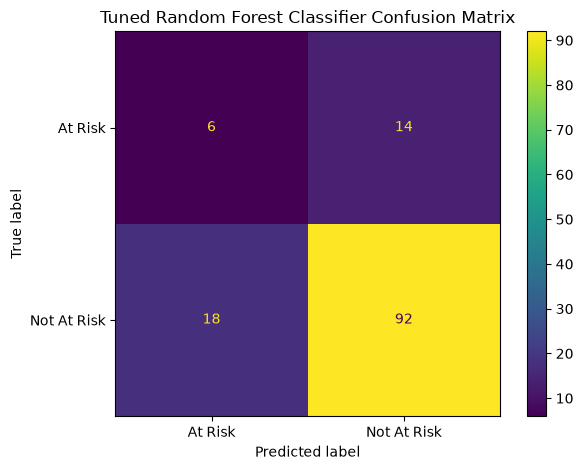

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_rf_classifier_cm,
    display_labels=["At Risk", "Not At Risk"]
)

disp.plot()

plt.title("Tuned Random Forest Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

### Compare initial vs tuned Random Forest

In [35]:
rf_tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Test Accuracy": [
        rf_classifier_accuracy,
        tuned_rf_classifier_accuracy
    ],
    "Test Precision": [
        rf_classifier_precision,
        tuned_rf_classifier_precision
    ],
    "Test Recall": [
        rf_classifier_recall,
        tuned_rf_classifier_recall
    ],
    "Test F1": [
        rf_classifier_f1,
        tuned_rf_classifier_f1
    ],
    "CV F1": [
        rf_classifier_cv_f1.mean(),
        rf_classifier_random_search.best_score_
    ]
})

rf_tuning_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1
0,Initial Random Forest,0.761538,0.869159,0.845455,0.857143,0.923343
1,Tuned Random Forest,0.753846,0.867925,0.836364,0.851852,0.914679


### At-Risk comparison

In [36]:
initial_rf_report = classification_report(
    y_test,
    rf_classifier_pred,
    output_dict=True,
    zero_division=0
)

tuned_rf_report = classification_report(
    y_test,
    tuned_rf_classifier_pred,
    output_dict=True,
    zero_division=0
)

rf_at_risk_tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "At Risk Precision": [
        initial_rf_report["0"]["precision"],
        tuned_rf_report["0"]["precision"]
    ],
    "At Risk Recall": [
        initial_rf_report["0"]["recall"],
        tuned_rf_report["0"]["recall"]
    ],
    "At Risk F1": [
        initial_rf_report["0"]["f1-score"],
        tuned_rf_report["0"]["f1-score"]
    ]
})

rf_at_risk_tuning_comparison

,Model,At Risk Precision,At Risk Recall,At Risk F1
0,Initial Random Forest,0.26087,0.3,0.279070
1,Tuned Random Forest,0.25000,0.3,0.272727


## Tuned Random Forest Evaluation

The best Random Forest configuration identified by RandomizedSearchCV
is now evaluated on the held-out test set.

The tuned model is compared with the initial Random Forest using
accuracy, precision, recall, F1-score, and class-specific performance.

The purpose is to determine whether hyperparameter tuning produces a
meaningful improvement in predictive performance.

In [37]:
tuned_rf_classifier = (
    rf_classifier_random_search.best_estimator_
)

tuned_rf_classifier_pred = (
    tuned_rf_classifier.predict(X_test)
)

tuned_rf_classifier_accuracy = accuracy_score(
    y_test,
    tuned_rf_classifier_pred
)

tuned_rf_classifier_precision = precision_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

tuned_rf_classifier_recall = recall_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

tuned_rf_classifier_f1 = f1_score(
    y_test,
    tuned_rf_classifier_pred,
    zero_division=0
)

print("Tuned Random Forest Classifier")
print("Accuracy :", tuned_rf_classifier_accuracy)
print("Precision:", tuned_rf_classifier_precision)
print("Recall   :", tuned_rf_classifier_recall)
print("F1-score :", tuned_rf_classifier_f1)

Tuned Random Forest Classifier
Accuracy : 0.7538461538461538
Precision: 0.8679245283018868
Recall   : 0.8363636363636363
F1-score : 0.8518518518518519


### Classification report

In [38]:
print(
    classification_report(
        y_test,
        tuned_rf_classifier_pred,
        target_names=["At Risk", "Not At Risk"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.25      0.30      0.27        20
 Not At Risk       0.87      0.84      0.85       110

    accuracy                           0.75       130
   macro avg       0.56      0.57      0.56       130
weighted avg       0.77      0.75      0.76       130



### Confusion matrix

In [39]:
tuned_rf_classifier_cm = confusion_matrix(
    y_test,
    tuned_rf_classifier_pred
)

print("Tuned Random Forest Confusion Matrix:")
print(tuned_rf_classifier_cm)

Tuned Random Forest Confusion Matrix:
[[ 6 14]
 [18 92]]


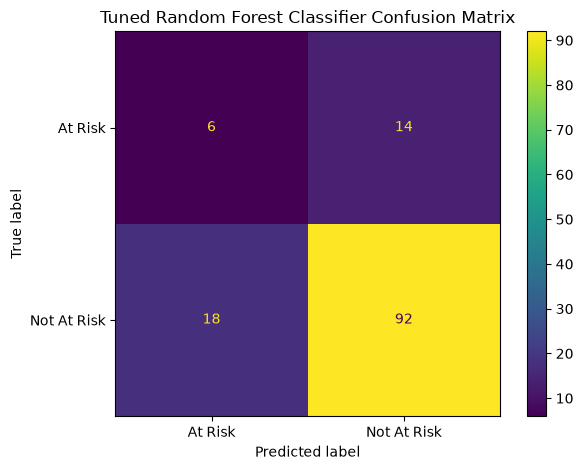

In [40]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_rf_classifier_cm,
    display_labels=["At Risk", "Not At Risk"]
)

disp.plot()

plt.title("Tuned Random Forest Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

### Compare Initial vs Tuned RF

In [41]:
rf_tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Test Accuracy": [
        rf_classifier_accuracy,
        tuned_rf_classifier_accuracy
    ],
    "Test Precision": [
        rf_classifier_precision,
        tuned_rf_classifier_precision
    ],
    "Test Recall": [
        rf_classifier_recall,
        tuned_rf_classifier_recall
    ],
    "Test F1": [
        rf_classifier_f1,
        tuned_rf_classifier_f1
    ],
    "CV F1": [
        rf_classifier_cv_f1.mean(),
        rf_classifier_random_search.best_score_
    ]
})

rf_tuning_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1
0,Initial Random Forest,0.761538,0.869159,0.845455,0.857143,0.923343
1,Tuned Random Forest,0.753846,0.867925,0.836364,0.851852,0.914679


### At-Risk comparison

In [42]:
initial_rf_report = classification_report(
    y_test,
    rf_classifier_pred,
    output_dict=True,
    zero_division=0
)

tuned_rf_report = classification_report(
    y_test,
    tuned_rf_classifier_pred,
    output_dict=True,
    zero_division=0
)

rf_at_risk_tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "At Risk Precision": [
        initial_rf_report["0"]["precision"],
        tuned_rf_report["0"]["precision"]
    ],
    "At Risk Recall": [
        initial_rf_report["0"]["recall"],
        tuned_rf_report["0"]["recall"]
    ],
    "At Risk F1": [
        initial_rf_report["0"]["f1-score"],
        tuned_rf_report["0"]["f1-score"]
    ]
})

rf_at_risk_tuning_comparison

,Model,At Risk Precision,At Risk Recall,At Risk F1
0,Initial Random Forest,0.26087,0.3,0.279070
1,Tuned Random Forest,0.25000,0.3,0.272727


## Classification Metric Selection

The classification target is encoded as:

- 0 = At Risk
- 1 = Not At Risk

Because the dataset is imbalanced, accuracy alone is not sufficient
for evaluating the models.

The primary evaluation focus is the minority At Risk class. Therefore,
macro F1-score is used to provide balanced performance across both
classes, while recall for the At Risk class is used as the main
application-oriented metric.

The earlier F1 results using the default positive class are retained
as exploratory results, but final model comparison uses metrics that
explicitly account for both classes and the At Risk objective.

### Create proper scorers

In [43]:
from sklearn.metrics import make_scorer

at_risk_recall_scorer = make_scorer(
    recall_score,
    pos_label=0
)

at_risk_f1_scorer = make_scorer(
    f1_score,
    pos_label=0
)

### Correct CV evaluation for the three models

In [44]:
classification_cv_results = []

models_for_cv = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_classifier_pipeline,
    "Random Forest": random_forest_classifier_pipeline
}

for model_name, model_pipeline in models_for_cv.items():

    macro_f1_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    at_risk_recall_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=at_risk_recall_scorer
    )

    at_risk_f1_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=at_risk_f1_scorer
    )

    classification_cv_results.append({
        "Model": model_name,
        "Mean CV Macro F1": macro_f1_scores.mean(),
        "Std CV Macro F1": macro_f1_scores.std(),
        "Mean CV At-Risk Recall": at_risk_recall_scores.mean(),
        "Mean CV At-Risk F1": at_risk_f1_scores.mean()
    })

classification_cv_results = pd.DataFrame(
    classification_cv_results
)

classification_cv_results.sort_values(
    "Mean CV Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Mean CV Macro F1,Std CV Macro F1,Mean CV At-Risk Recall,Mean CV At-Risk F1
0,Random Forest,0.735173,0.027504,0.5125,0.547003
1,Logistic Regression,0.707937,0.035295,0.7375,0.539713
2,Decision Tree,0.669706,0.084347,0.4125,0.438324


### Final test comparison

In [45]:
classification_test_results = []

test_models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": dt_classifier_pred,
    "Random Forest": rf_classifier_pred,
    "Tuned Random Forest": tuned_rf_classifier_pred
}

for model_name, predictions in test_models.items():

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    classification_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),
        "At-Risk Precision": report["0"]["precision"],
        "At-Risk Recall": report["0"]["recall"],
        "At-Risk F1": report["0"]["f1-score"]
    })

classification_test_results = pd.DataFrame(
    classification_test_results
)

classification_test_results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Macro F1,At-Risk Precision,At-Risk Recall,At-Risk F1
0,Random Forest,0.761538,0.568106,0.260870,0.30,0.279070
1,Tuned Random Forest,0.753846,0.562290,0.250000,0.30,0.272727
2,Logistic Regression,0.653846,0.528644,0.209302,0.45,0.285714
3,Decision Tree,0.707692,0.498171,0.153846,0.20,0.173913


## Final Classification Model Selection

The classification results show a trade-off between overall predictive
performance and detection of students who are at risk.

Random Forest achieved the strongest overall performance, obtaining the
highest test accuracy and Macro F1-score and the highest mean
cross-validation Macro F1-score.

However, Logistic Regression achieved the highest recall for the
minority At Risk class in both cross-validation and the held-out test
set. It also achieved the highest At-Risk F1-score on the test set.

Therefore, Random Forest is selected as the best overall classification
model, while Logistic Regression is identified as the more suitable
model when the primary objective is maximizing detection of At-Risk
students.

The final model choice therefore depends on the application objective:
Random Forest provides stronger overall classification performance,
whereas Logistic Regression provides greater sensitivity to the
minority At-Risk class.

### Create a final recommendation table

In [46]:
final_model_recommendation = pd.DataFrame({
    "Objective": [
        "Best overall classification",
        "Best At-Risk detection"
    ],
    "Recommended Model": [
        "Random Forest",
        "Logistic Regression"
    ],
    "Reason": [
        "Highest test Macro F1 and strongest overall CV performance",
        "Highest At-Risk recall and strongest At-Risk sensitivity"
    ]
})

final_model_recommendation

,Objective,Recommended Model,Reason
0,Best overall classification,Random Forest,Highest test Macro F1 and strongest overall CV...
1,Best At-Risk detection,Logistic Regression,Highest At-Risk recall and strongest At-Risk s...


## Corrected Random Forest Tuning Evaluation

Because the classification problem is imbalanced, the initial and tuned
Random Forest models are compared using the same evaluation metrics used
for final model selection.

Five-fold stratified cross-validation is used to compare Macro F1 and
At-Risk Recall. This provides a consistent basis for determining whether
hyperparameter tuning improves the Random Forest.

In [47]:
tuned_rf_cv_macro_f1 = cross_val_score(
    tuned_rf_classifier,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

tuned_rf_cv_at_risk_recall = cross_val_score(
    tuned_rf_classifier,
    X_train,
    y_train,
    cv=cv,
    scoring=at_risk_recall_scorer
)

initial_rf_cv_macro_f1 = cross_val_score(
    random_forest_classifier_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

initial_rf_cv_at_risk_recall = cross_val_score(
    random_forest_classifier_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=at_risk_recall_scorer
)

rf_corrected_tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV Macro F1": [
        initial_rf_cv_macro_f1.mean(),
        tuned_rf_cv_macro_f1.mean()
    ],
    "Mean CV At-Risk Recall": [
        initial_rf_cv_at_risk_recall.mean(),
        tuned_rf_cv_at_risk_recall.mean()
    ],
    "Test Macro F1": [
        f1_score(
            y_test,
            rf_classifier_pred,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            tuned_rf_classifier_pred,
            average="macro",
            zero_division=0
        )
    ],
    "Test At-Risk Recall": [
        initial_rf_report["0"]["recall"],
        tuned_rf_report["0"]["recall"]
    ]
})

rf_corrected_tuning_comparison

,Model,Mean CV Macro F1,Mean CV At-Risk Recall,Test Macro F1,Test At-Risk Recall
0,Initial Random Forest,0.735173,0.5125,0.568106,0.3
1,Tuned Random Forest,0.739588,0.6000,0.562290,0.3


## Hyperparameter Tuning Conclusion

RandomizedSearchCV was used to explore alternative Random Forest
hyperparameter configurations.

Based on five-fold stratified cross-validation, the tuned Random
Forest achieved a higher Macro F1-score than the initial Random Forest
(0.7396 compared with 0.7352). It also achieved higher mean At-Risk
recall during cross-validation (0.6000 compared with 0.5125).

Therefore, the tuned Random Forest is selected as the preferred
Random Forest configuration based on cross-validation performance.

When evaluated on the held-out test set, however, the tuned model
achieved a slightly lower Macro F1-score than the initial Random
Forest (0.5623 compared with 0.5681), while both models achieved an
At-Risk recall of 30%.

This difference between cross-validation and test performance
highlights the importance of evaluating generalization on a held-out
dataset. The tuned model is retained as the selected model because
model selection was based on cross-validation rather than the held-out
test results.

## Random Forest Feature Importance

Feature importance is examined for the selected Random Forest model to
identify which transformed student characteristics contribute most to
the model's predictions.

Because categorical variables are one-hot encoded during preprocessing,
the importance values are calculated for the transformed feature
representation.

In [48]:
# Fit the preprocessor separately to obtain transformed feature names
rf_preprocessor = tuned_rf_classifier.named_steps[
    "preprocessor"
]

rf_model = tuned_rf_classifier.named_steps[
    "model"
]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,num__failures,0.101574
1,cat__school_GP,0.071332
2,cat__school_MS,0.066677
3,cat__higher_no,0.048554
4,cat__higher_yes,0.043440
5,num__absences,0.039860
6,num__Medu,0.036699
7,num__goout,0.034551
8,num__Walc,0.033504
9,num__Fedu,0.033174


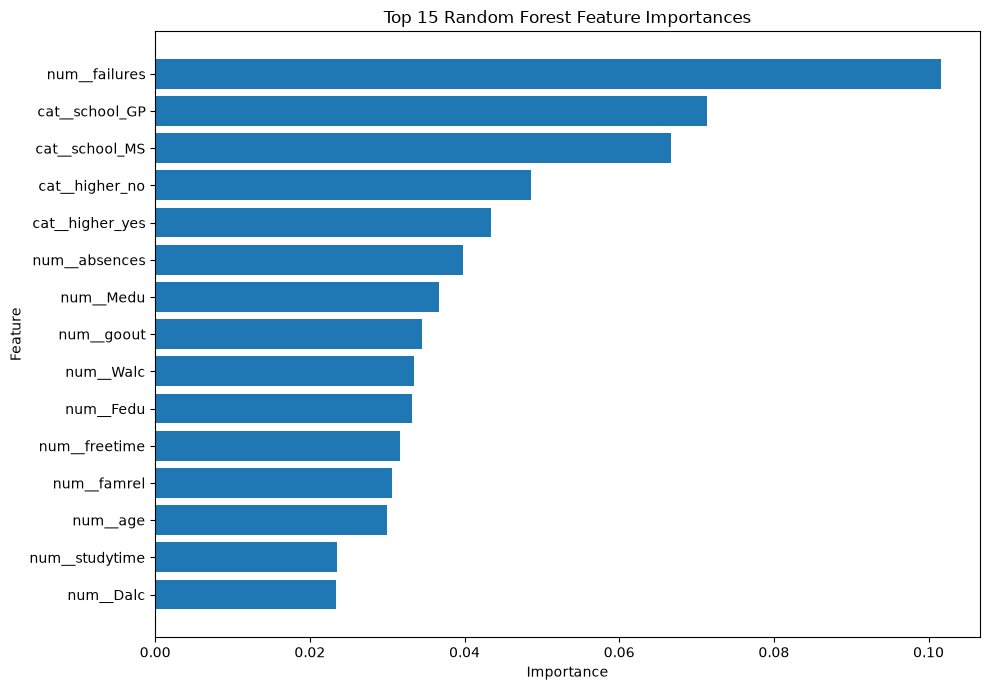

In [49]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Classification Results Interpretation

Three classification approaches were evaluated: Logistic Regression,
Decision Tree, and Random Forest. Random Forest was further evaluated
using RandomizedSearchCV for hyperparameter optimization.

The tuned Random Forest achieved the strongest cross-validation
performance among the evaluated Random Forest configurations, with a
Macro F1-score of 0.7396 and an At-Risk recall of 0.6000. It was
therefore selected as the preferred overall Random Forest model based
on cross-validation.

On the held-out test set, the tuned Random Forest achieved an accuracy
of 75.38% and a Macro F1-score of 0.5623. The initial Random Forest
achieved slightly higher test accuracy and Macro F1, but this difference
was not used to change the model selection because the test set should
not be used for model selection.

Logistic Regression demonstrated the strongest sensitivity to the
minority At-Risk class among the initial classification models. It
achieved an At-Risk recall of 45% on the held-out test set and a
cross-validation At-Risk recall of 73.75%.

These results demonstrate a trade-off between overall classification
performance and minority-class detection. The tuned Random Forest is
selected as the overall model based on cross-validation, while Logistic
Regression provides a useful alternative when maximizing detection of
At-Risk students is the primary objective.

## Classification Limitations

Several limitations should be considered when interpreting the
classification results.

1. The dataset contains a substantial class imbalance, with At-Risk
   students representing a minority of the observations.

2. The held-out test set contains only a limited number of At-Risk
   students. Therefore, small changes in predictions can noticeably
   affect minority-class metrics.

3. The classification models use early student characteristics and do
   not use G1 or G2. This supports an early-prediction scenario but
   also limits the information available to the models.

4. The relatively low At-Risk recall of the final models indicates that
   the dataset and selected features do not allow reliable identification
   of all students at risk.

5. The results should therefore be interpreted as predictive patterns
   within this dataset rather than as a complete student-risk
   assessment system.

# Classification Conclusion

The classification experiment successfully compared multiple machine
learning approaches for identifying students at risk of poor final
academic performance.

Logistic Regression, Decision Tree, and Random Forest classifiers were
evaluated using stratified cross-validation and held-out test-set
metrics.

Random Forest demonstrated the strongest overall classification
performance among the initial models. Hyperparameter tuning further
improved its cross-validation performance, and the tuned Random Forest
was selected as the final overall classifier based on cross-validation.

However, the tuned model did not achieve higher performance on the
held-out test set than the initial Random Forest. This difference
illustrates the importance of separating model selection from final
generalization assessment.

Logistic Regression demonstrated stronger sensitivity toward the
minority At-Risk class, particularly in terms of At-Risk recall.
Therefore, although the tuned Random Forest is selected as the overall
model, Logistic Regression may be preferable in applications where
identifying as many At-Risk students as possible is the primary
objective.

Overall, the classification results indicate that early student
demographic, academic-behavioural, family, social, and lifestyle
characteristics contain useful information for predicting academic
risk. However, the relatively low test-set recall for the At-Risk
class indicates that further data, feature engineering, class-
imbalance strategies, or alternative modelling approaches may be
required for a more reliable early-warning system.